# 02 - Exploratory analysis

Track 2 (popularity prediction). Looks at the target, the audio features and how they relate to
popularity, mainly to decide which features and what kind of model to use. Figures are saved to
`reports/figures/` for the slides.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from scipy import stats

from src.data_prep import AUDIO_FEATURES, load_raw, PROCESSED_DIR
from src import plots

plots.set_style()
pd.set_option("display.float_format", "{:,.3f}".format)

df = pd.read_csv(PROCESSED_DIR / "spotify_clean.csv")
raw = load_raw()
print(f"{len(df):,} songs, {df['song_genre'].nunique()} genres, {df['primary_artist'].nunique():,} primary artists")

81,181 songs, 114 genres, 17,635 primary artists


## 1. Target: popularity

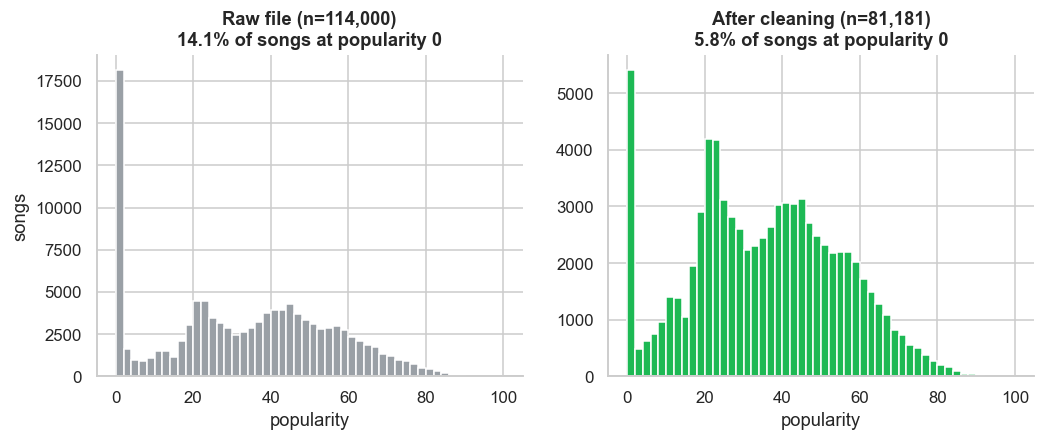

In [2]:
plots.popularity_before_after(raw, df);

In [3]:
df["popularity"].describe()

count   81,181.000
mean        35.251
std         19.418
min          0.000
25%         21.000
50%         35.000
75%         50.000
max        100.000
Name: popularity, dtype: float64

After cleaning, popularity is roughly bell-shaped around 35 with a long right tail. Half the songs
are between 21 and 50 and only ~10% reach 61 or more. The bar at 0 (~6%) that's left should be real
low-play songs.

Predicting ~35 for every song is already only off by ~16-17 points on average, so that's the
baseline to beat. Models will probably under-predict the hits in the tail.

## 2. Audio features

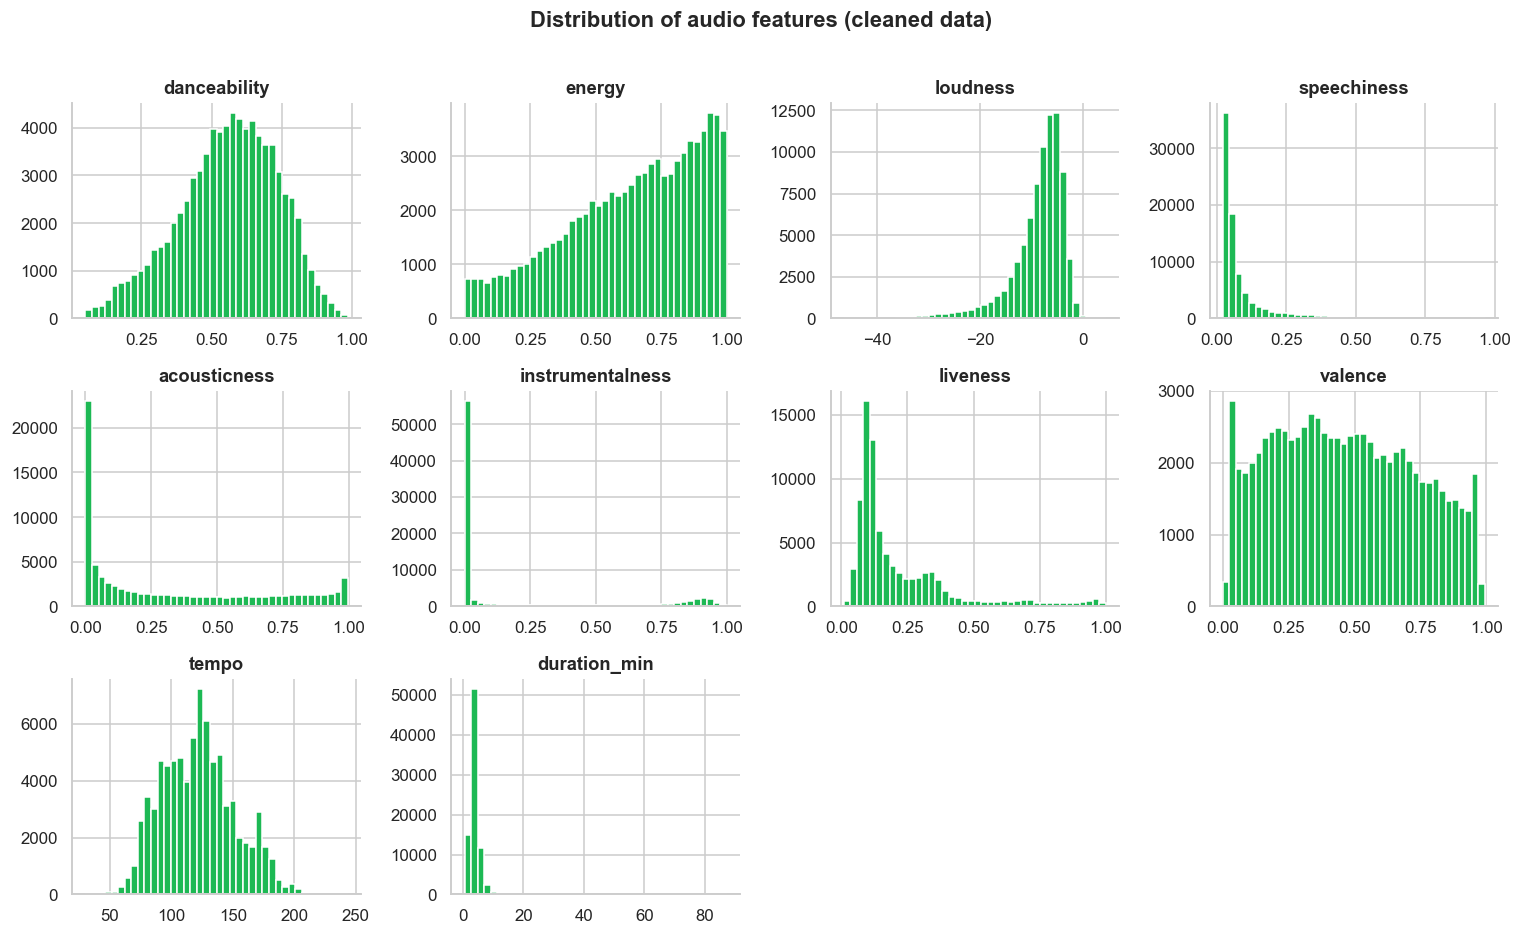

In [4]:
plots.feature_distributions(df, AUDIO_FEATURES + ["duration_min"]);

In [5]:
df[AUDIO_FEATURES + ["duration_min"]].describe().T[["mean", "50%", "std", "min", "max"]]

,mean,50%,std,min,max
danceability,0.560,0.574,0.176,0.051,0.985
energy,0.636,0.678,0.258,0.000,1.000
loudness,-8.571,-7.258,5.257,-46.591,4.532
speechiness,0.089,0.049,0.117,0.022,0.965
acousticness,0.329,0.190,0.340,0.000,0.996
instrumentalness,0.184,0.000,0.331,0.000,1.000
liveness,0.219,0.133,0.198,0.009,1.000
valence,0.464,0.449,0.263,0.000,0.995
tempo,122.355,122.047,29.704,30.200,243.372
duration_min,3.859,3.588,1.920,0.501,87.288


Most features are far from normal. `speechiness`, `liveness` and `instrumentalness` pile up near 0
with long tails, and `instrumentalness` is basically either ~0 or close to 1 (vocals or not), which
is why we added `is_instrumental`. `acousticness` is U-shaped and `loudness` is left-skewed. Fine for
tree models; linear models need scaling at least.

## 3. Correlations between features

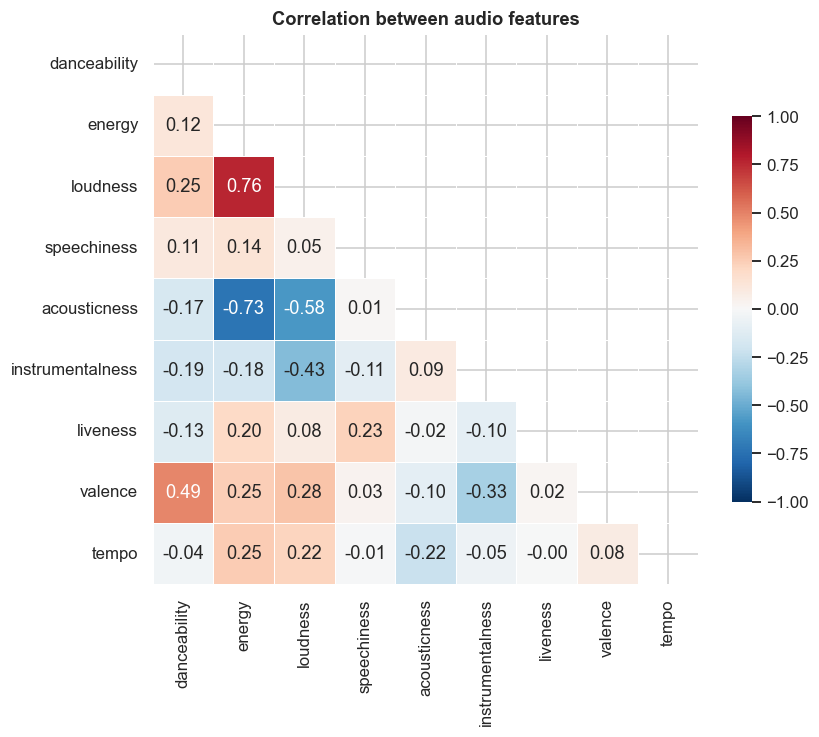

In [6]:
plots.correlation_heatmap(df, AUDIO_FEATURES);

Strongest pairs: `energy`-`loudness` (0.76), `energy`-`acousticness` (-0.73) and
`danceability`-`valence` (0.49). Energy, loudness and acousticness are more or less one axis (loud
produced track vs quiet acoustic one). For linear regression we should keep only one of them or use
Ridge/Lasso. Random forest can handle it, but it will split importance between the three, so keep
that in mind when reading feature importances.

## 4. Features vs popularity

In [7]:
features = AUDIO_FEATURES + ["duration_min"]
assoc = pd.DataFrame({
    "pearson": df[features].corrwith(df["popularity"]),
    "spearman": df[features].corrwith(df["popularity"], method="spearman"),
}).sort_values("pearson")
assoc

,pearson,spearman
instrumentalness,-0.188,-0.193
speechiness,-0.070,-0.092
duration_min,-0.057,-0.029
acousticness,-0.043,0.026
liveness,-0.036,-0.028
tempo,0.001,-0.001
energy,0.006,-0.034
valence,0.021,0.021
danceability,0.097,0.085
loudness,0.102,0.095


Each feature on its own has a weak linear correlation with popularity, the strongest is
`instrumentalness` at -0.19. That would suggest audio barely matters, but the decile plot below
shows the correlations are hiding the shape.

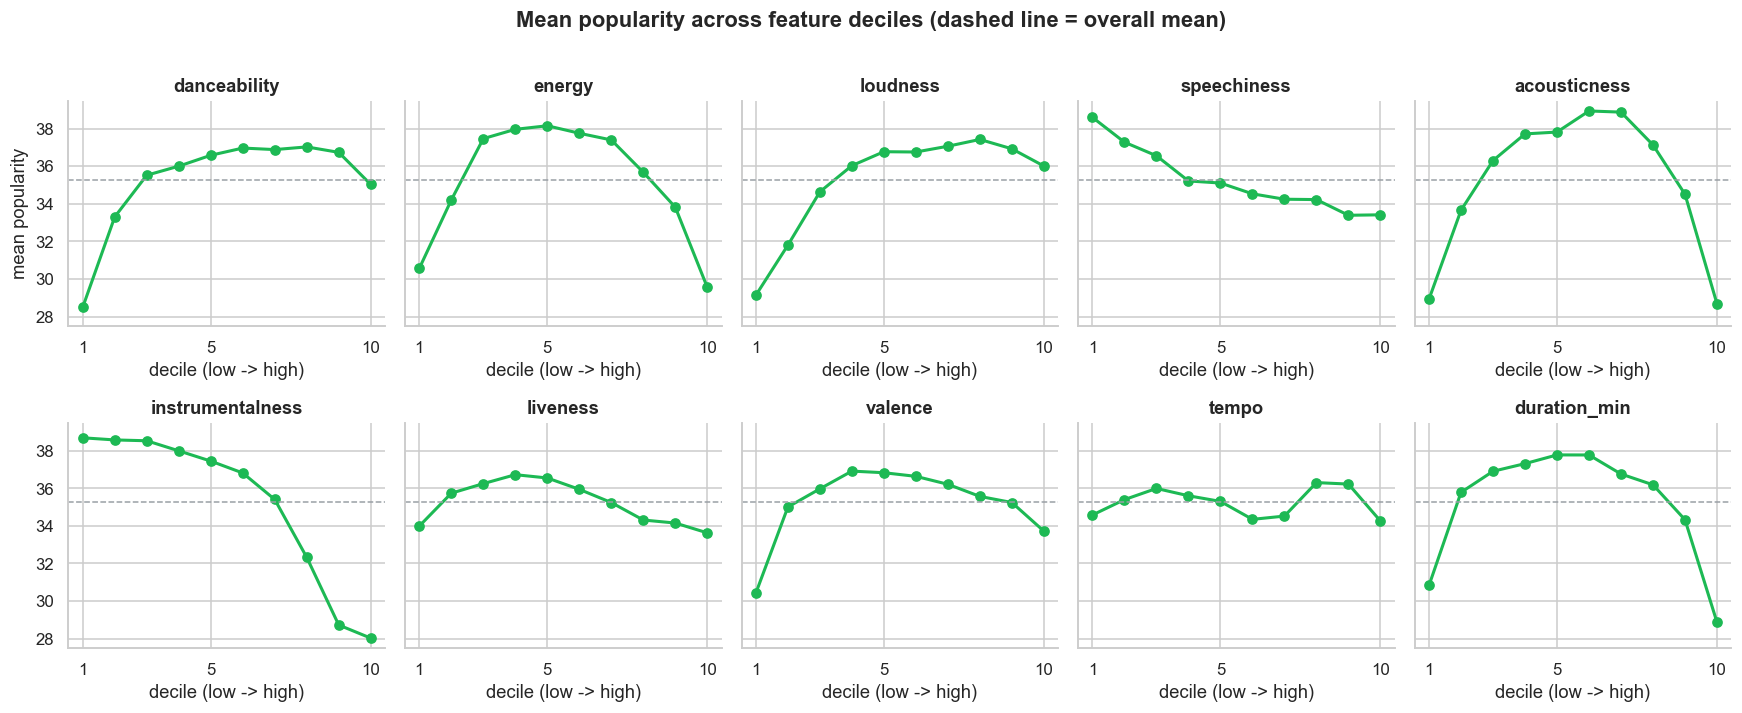

In [8]:
plots.decile_profile(df, features);

`energy`, `acousticness`, `valence` and `duration_min` look like an inverted U: popularity peaks in
the middle deciles and drops at both ends (e.g. very short and very long songs both do worse). A
correlation coefficient averages the two halves, so it ends up near 0. `danceability` mostly goes
up, with a small dip in the top decile.

`instrumentalness` drops sharply in the top 3 deciles (songs with no vocals), quiet tracks do worse
on `loudness`, and `speechiness` slowly declines. `tempo` only moves ~2 points across deciles, so
nothing there.

So we expect tree models (decision tree, random forest, boosting) to beat plain linear regression.
The linear baseline is still worth running, maybe with squared terms for energy, acousticness,
valence and duration to see how much of the gap is just the curvature.

## 5. Genre

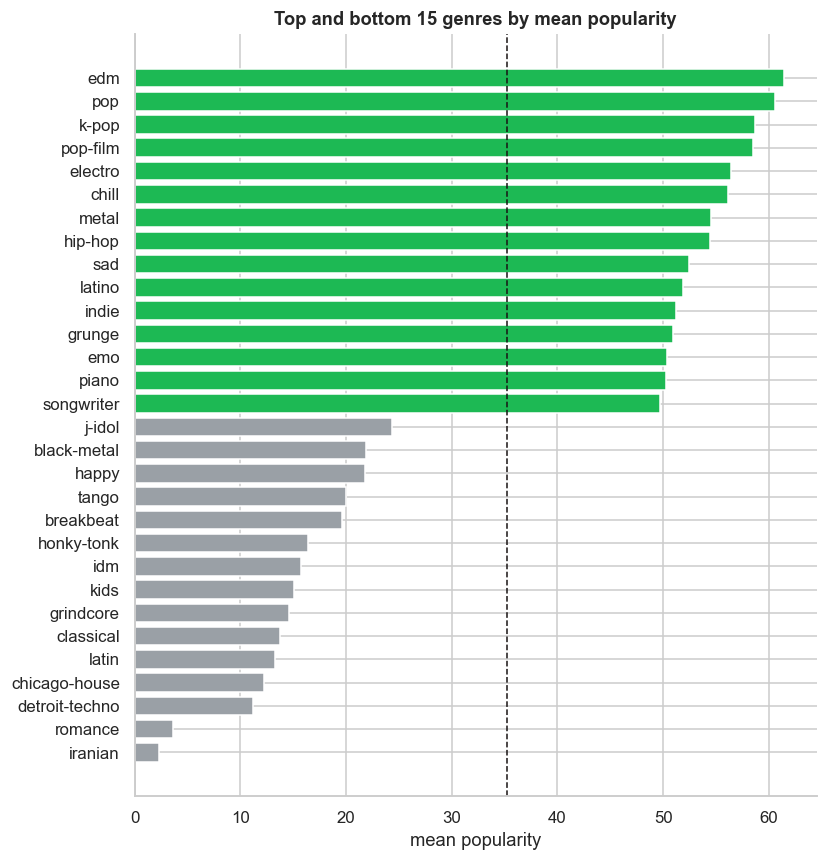

In [9]:
plots.genre_ranking(df);

In [10]:
genre_mean = df.groupby("song_genre")["popularity"].transform("mean")
eta_sq = 1 - ((df["popularity"] - genre_mean) ** 2).sum() / ((df["popularity"] - df["popularity"].mean()) ** 2).sum()
kruskal_p = stats.kruskal(*[g["popularity"] for _, g in df.groupby("song_genre")]).pvalue
print(f"share of popularity variance explained by genre alone (eta^2): {eta_sq:.1%}")
print(f"Kruskal-Wallis test across genres: p = {kruskal_p:.1e}")

share of popularity variance explained by genre alone (eta^2): 40.8%
Kruskal-Wallis test across genres: p = 0.0e+00


Genre alone explains ~41% of the variance in popularity, probably more than all the audio features
together. Mainstream genres (EDM, pop, k-pop, hip-hop) average around 54-61, while iranian, romance
and the house/techno sub-genres are at the bottom.

We wouldn't read too much into the very bottom though. Iranian and romance average under 4 with a
median of 0, which is more likely about how those 1,000-song lists were filled (old or obscure
catalogue) than about the genre itself. Latin also has a median of just 1. Genre should stay in as
a feature, but we shouldn't say things like "romance songs fail" in the presentation.

## 6. Are audio features just a proxy for genre?

,overall,within genre
instrumentalness,-0.188,-0.035
speechiness,-0.070,-0.033
acousticness,-0.043,-0.017
liveness,-0.036,-0.040
tempo,0.001,-0.004
energy,0.006,-0.018
valence,0.021,-0.019
danceability,0.097,0.030
loudness,0.102,0.021


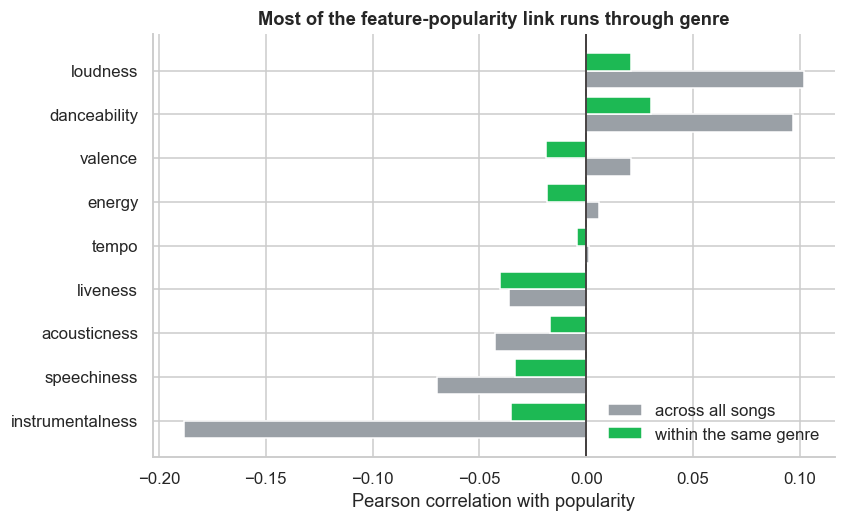

In [11]:
fig, within = plots.overall_vs_within_genre(df, AUDIO_FEATURES)
within.round(3)

Once we subtract each genre's mean (so songs are only compared within their own genre), the
audio-popularity correlations mostly disappear. E.g. instrumental songs look less popular mainly
because instrumental-heavy genres (classical, ambient, techno) are less popular, not because they
lose within their own genre. Probably the most important result in this notebook.

What it means for modeling:

1. Train each model twice, audio only and audio + genre. The gap shows how much popularity depends
   on the sound itself vs the genre.
2. In the audio + genre model, genre will dominate feature importance, so use the audio-only model
   when giving advice to artists.
3. Claims like "X helps within pop" need a within-genre check, not just the overall correlation.

## 7. Explicit, instrumental, multi-genre, collaborations

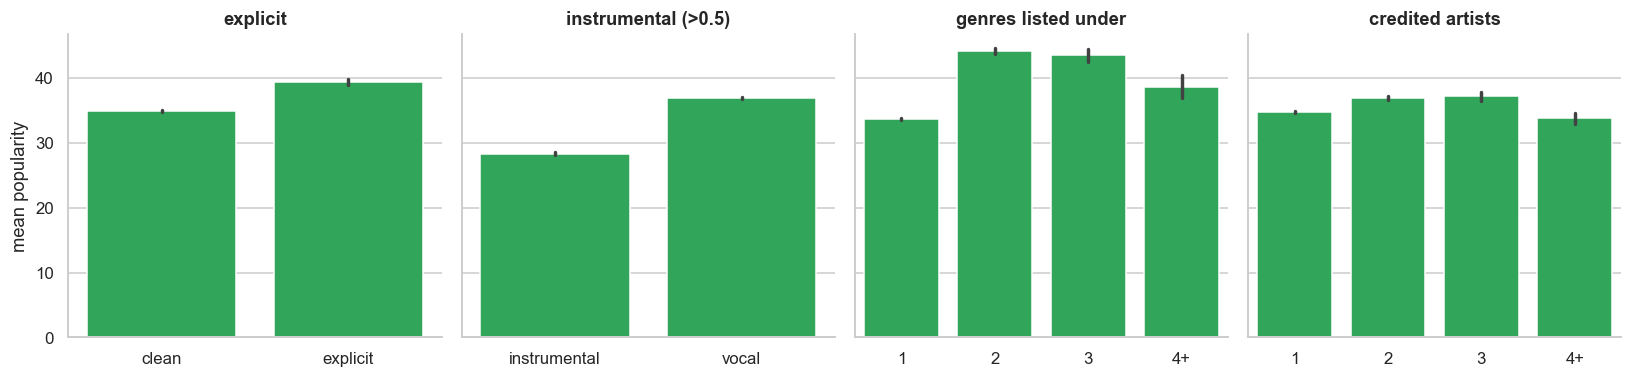

In [12]:
plots.flag_comparison(df);

In [13]:
def compare(flag):
    a, b = df.loc[df[flag] == 1, "popularity"], df.loc[df[flag] == 0, "popularity"]
    p = stats.mannwhitneyu(a, b).pvalue
    return pd.Series({"mean if 1": a.mean(), "mean if 0": b.mean(), "difference": a.mean() - b.mean(), "n if 1": len(a), "Mann-Whitney p": p})

pd.DataFrame({flag: compare(flag) for flag in ["explicit", "is_instrumental", "is_live"]}).T

,mean if 1,mean if 0,difference,n if 1,Mann-Whitney p
explicit,39.402,34.862,4.540,"6,963.000",0.000
is_instrumental,28.335,36.945,-8.610,"15,970.000",0.000
is_live,33.506,35.312,-1.806,"2,726.000",0.000


In [14]:
df.groupby(df["n_genres"].clip(upper=4))["popularity"].agg(["mean", "median", "size"])

,mean,median,size
n_genres,,,
1,33.645,32.000,68056
2,44.175,46.000,9705
3,43.488,47.000,2286
4,38.668,46.000,1134


- Explicit songs average ~4.5 points higher, but only 9% of songs are explicit and they're mostly in
  hip-hop and similar genres, so this is partly genre again.
- Instrumental songs are ~8.6 points lower, the biggest gap of these flags.
- Live recordings are slightly lower.
- 2-3 credited artists average ~2 points more than solo songs, 4+ drops back. Small effect.
- Songs listed under several genres are ~10 points higher than single-genre songs. Big gap, but it
  could come from how the data was collected (a popular song is more likely to show up when you
  search genre by genre), so `n_genres` may partly reflect popularity rather than cause it. We'd
  leave it out of the main model and test it separately.

## 8. What do the top songs look like?

,std. difference (top 10% - rest)
instrumentalness,-0.370
liveness,-0.220
acousticness,-0.180
duration_min,-0.130
speechiness,-0.090
tempo,-0.070
energy,0.020
valence,0.090
loudness,0.190
danceability,0.230


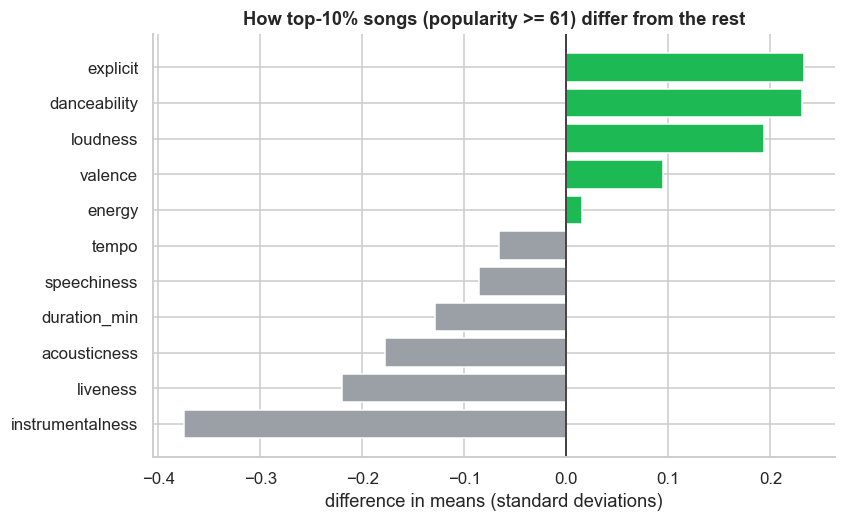

In [15]:
profile_features = AUDIO_FEATURES + ["duration_min", "explicit"]
fig, gap = plots.hits_vs_rest(df, profile_features)
gap.round(2).to_frame("std. difference (top 10% - rest)")

Top 10% songs (popularity >= 61) are more danceable, louder and more often explicit, with clearly
less instrumental, live and acoustic content. They're also a bit shorter. Tempo, energy and valence
are about the same. This matches the decile plots, but again a lot of it is genre mix (section 6).

## 9. Notes for the modeling side

- Data: `data/processed/spotify_clean.csv`, one row per song (81,181 songs). Use the `split` column
  (80/20, grouped by primary artist, seed 42): fit and cross-validate on `train`, use `test` once at
  the end.
- Target: `popularity` (0-100).
- Feature set A (audio only): danceability, energy, loudness, speechiness, acousticness,
  instrumentalness, liveness, valence, tempo, duration_min, explicit, mode, key, time_signature.
- Feature set B: A + one-hot `song_genre`.
- Optional extras: n_artists, is_instrumental, is_live, n_genres (see section 7).
- Not inputs: song_id, song_name, album_name, artists, primary_artist. They identify the song, they
  don't describe it.
- Baseline: predicting the train mean gives test MAE ~16.6. Report MAE, RMSE and R^2 against that.
- Linear models: scale the features, and keep only one of energy/loudness/acousticness or
  regularise.
- If you add an artist- or genre-level average popularity as a feature, compute it on the training
  fold only, otherwise it leaks the target.
- For advice to artists, use the audio-only model and check the effect also holds within genre.